https://www.kaggle.com/code/kadircandrisolu/transforming-audio-to-mel-spec-birdclef-25/comments

Modifed this to use a bit more gpu for faster stuff

In [9]:
import os
import cv2
import math
import time
import librosa
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import torch
import torchaudio
import warnings
warnings.filterwarnings("ignore")

In [ ]:
class Config:
 
    DEBUG_MODE = False
    
    OUTPUT_DIR = 'working' #change as needed
    DATA_ROOT = 'Data' #change as needed
    FS = 32000
    # Mel spectrogram parameters
    N_FFT = 1024
    HOP_LENGTH = 512
    N_MELS = 128
    FMIN = 50
    FMAX = 14000
    TARGET_DURATION = 5.0 #
    TARGET_SHAPE = (256, 256)  
    
    N_MAX = 500 if DEBUG_MODE else None  

config = Config()

In [5]:
print(f"Debug mode: {'ON' if config.DEBUG_MODE else 'OFF'}")
print(f"Max samples to process: {config.N_MAX if config.N_MAX is not None else 'ALL'}")

print("Loading taxonomy data...")
taxonomy_df = pd.read_csv(f'{config.DATA_ROOT}/taxonomy.csv')
species_class_map = dict(zip(taxonomy_df['primary_label'], taxonomy_df['class_name']))

print("Loading training metadata...")
train_df = pd.read_csv(f'{config.DATA_ROOT}/train.csv')
print("done")



Debug mode: OFF
Max samples to process: ALL
Loading taxonomy data...
Loading training metadata...
done


In [6]:
label_list = sorted(train_df['primary_label'].unique())
label_id_list = list(range(len(label_list)))
label2id = dict(zip(label_list, label_id_list))
id2label = dict(zip(label_id_list, label_list))

print(f'Found {len(label_list)} unique species')
working_df = train_df[['primary_label', 'rating', 'filename']].copy()
working_df['target'] = working_df.primary_label.map(label2id)
working_df['filepath'] = config.DATA_ROOT + '/train_audio/' + working_df.filename
working_df['samplename'] = working_df.filename.map(lambda x: x.split('/')[0] + '-' + x.split('/')[-1].split('.')[0])
working_df['class'] = working_df.primary_label.map(lambda x: species_class_map.get(x, 'Unknown'))
total_samples = min(len(working_df), config.N_MAX or len(working_df))
print(f'Total samples to process: {total_samples} out of {len(working_df)} available')
print(f'Samples by class:')
print(working_df['class'].value_counts())

Found 206 unique species
Total samples to process: 28564 out of 28564 available
Samples by class:
class
Aves        27648
Amphibia      583
Mammalia      178
Insecta       155
Name: count, dtype: int64


In [ ]:
# === TORCH AUDIO SETUP ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=config.FS,
    n_fft=config.N_FFT,
    hop_length=config.HOP_LENGTH,
    n_mels=config.N_MELS,
    f_min=config.FMIN,
    f_max=config.FMAX,
    power=2.0
).to(device)

db_transform = torchaudio.transforms.AmplitudeToDB().to(device)

# === HELPER FUNCTION ===
def audio2melspec(audio_data):
    if np.isnan(audio_data).any():
        mean_signal = np.nanmean(audio_data)
        audio_data = np.nan_to_num(audio_data, nan=mean_signal)

    waveform = torch.tensor(audio_data, dtype=torch.float32, device=device).unsqueeze(0)
    mel_spec = mel_transform(waveform)
    mel_spec_db = db_transform(mel_spec)

    mel_spec_db -= mel_spec_db.min()
    mel_spec_db /= mel_spec_db.max() + 1e-8

    return mel_spec_db.squeeze(0).cpu().numpy()

# === SAVE DIRECTORY SETUP ===
SAVE_DIR = os.path.join(config.OUTPUT_DIR, "mel_spectrograms")
os.makedirs(SAVE_DIR, exist_ok=True)

# === MAIN PROCESSING LOOP ===
print("Starting audio processing...")
print(f"{'DEBUG MODE - Processing only 50 samples' if config.DEBUG_MODE else 'FULL MODE - Processing all samples'}")
start_time = time.time()

all_bird_data = {}
errors = []

# must define working_df and total_samples before this loop
# working_df = pd.read_csv(...) or however you're loading it
# total_samples = len(working_df)

for i, row in tqdm(working_df.iterrows(), total=total_samples):
    if config.N_MAX is not None and i >= config.N_MAX:
        break
    try:
        audio_data, _ = librosa.load(row.filepath, sr=config.FS)
        target_samples = int(config.TARGET_DURATION * config.FS)

        if len(audio_data) < target_samples:
            audio_data = np.tile(audio_data, int(np.ceil(target_samples / len(audio_data))))
        center_audio = audio_data[:target_samples]

        if len(center_audio) < target_samples:
            center_audio = np.pad(center_audio, (0, target_samples - len(center_audio)))

        mel_spec = audio2melspec(center_audio)

        if mel_spec.shape != config.TARGET_SHAPE:
            mel_spec = cv2.resize(mel_spec, config.TARGET_SHAPE, interpolation=cv2.INTER_LINEAR)

        mel_spec = mel_spec.astype(np.float32)
        all_bird_data[row.samplename] = mel_spec

        # === Save as .npy in class-specific subfolder ===
        class_folder = os.path.join(SAVE_DIR, row['class'])
        os.makedirs(class_folder, exist_ok=True)

        save_path = os.path.join(class_folder, f"{row.samplename}.npy")
        np.save(save_path, mel_spec)

    except Exception as e:
        print(f"Error processing {row.filepath}: {e}")
        errors.append((row.filepath, str(e)))

# === DONE ===
end_time = time.time()
print(f"\nProcessing completed in {end_time - start_time:.2f} seconds")
print(f"Successfully processed {len(all_bird_data)} files out of {total_samples}")
print(f"Failed to process {len(errors)} files")

Starting audio processing...
FULL MODE - Processing all samples


  0%|          | 0/28564 [00:00<?, ?it/s]


Processing completed in 1417.04 seconds
Successfully processed 28564 files out of 28564
Failed to process 0 files


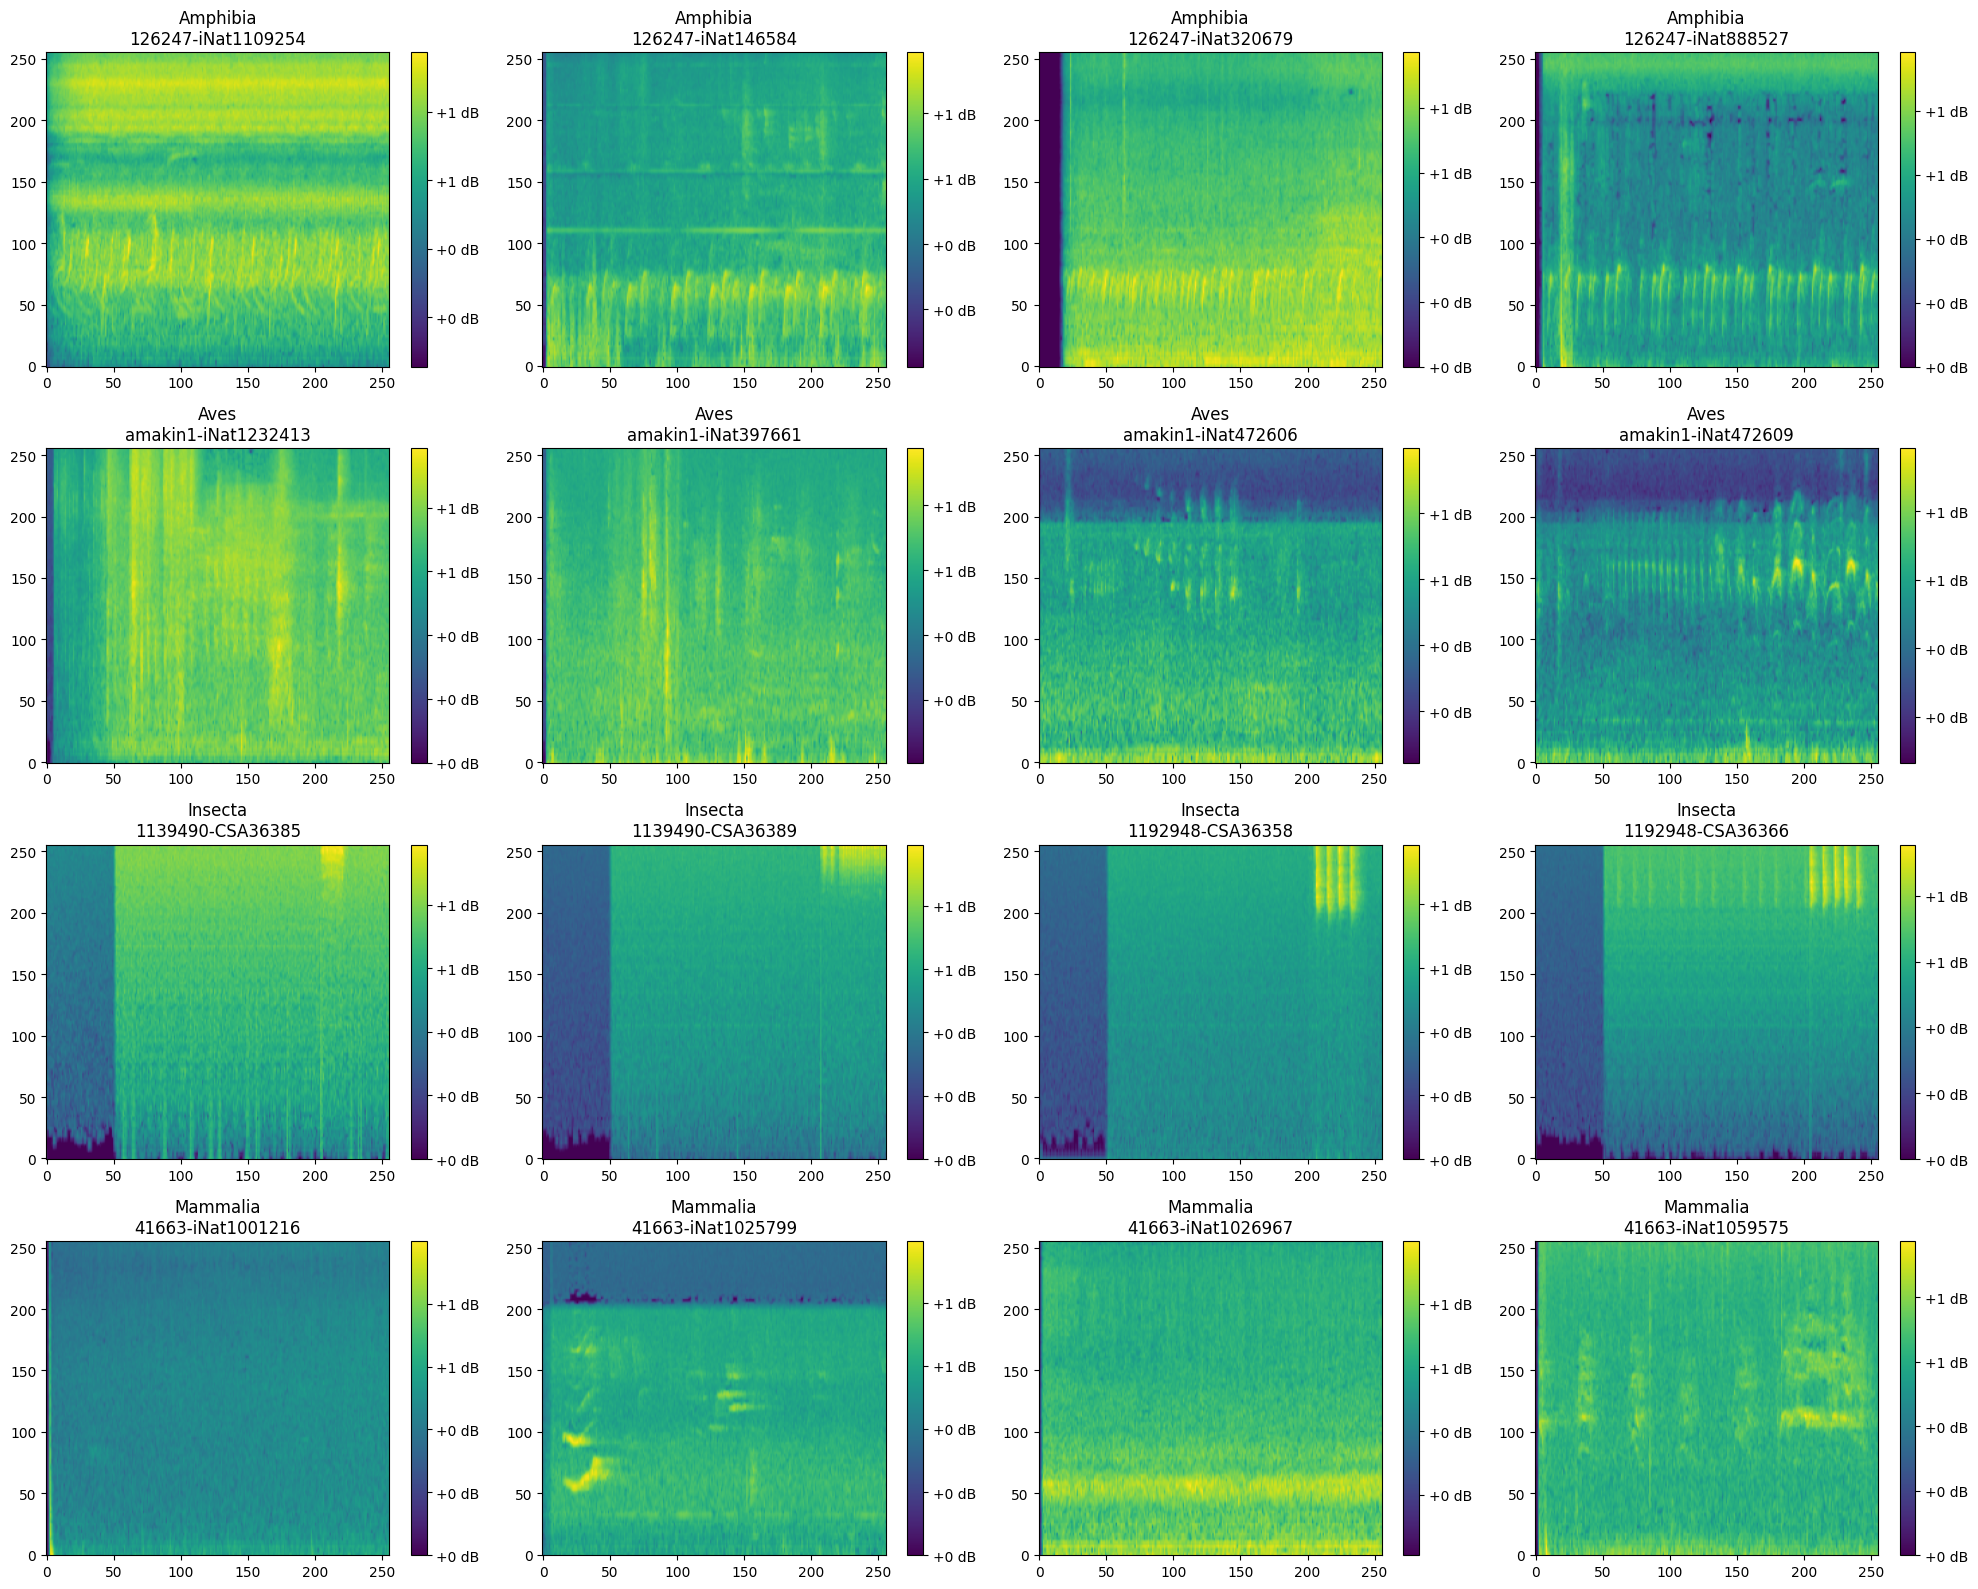

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path

# === Step 1: Setup ===
LOAD_DIR = os.path.join(config.OUTPUT_DIR, "mel_spectrograms")

class_samples = defaultdict(list)
max_classes = 4
samples_per_class = 4

# Recursively find all .npy files
npy_files = list(Path(LOAD_DIR).rglob("*.npy"))

# === Step 2: Load samples grouped by class ===
for file_path in npy_files:
    samplename = file_path.stem
    class_name = file_path.parent.name  # subfolder name = class

    if len(class_samples[class_name]) < samples_per_class:
        mel = np.load(file_path, mmap_mode='r')
        class_samples[class_name].append((samplename, mel))

    # Stop if we have enough samples
    if len(class_samples) >= max_classes and all(len(v) >= samples_per_class for v in class_samples.values()):
        break

# === Step 3: Plot ===
plt.figure(figsize=(samples_per_class * 5, max_classes * 4))

plot_index = 1
for class_name, items in list(class_samples.items())[:max_classes]:
    for samplename, mel_spec in items:
        plt.subplot(max_classes, samples_per_class, plot_index)
        plt.imshow(mel_spec, aspect='auto', origin='lower', cmap='viridis')
        plt.title(f"{class_name}\n{samplename}")
        plt.colorbar(format='%+2.0f dB')
        plot_index += 1

plt.tight_layout()
plt.show()


In [13]:
import os
import numpy as np
from tqdm import tqdm

LOAD_DIR = os.path.join(config.OUTPUT_DIR, "mel_spectrograms")

# Load all .npy files into a dictionary: {samplename: mel_spec}
loaded_bird_data = {}

for filename in tqdm(os.listdir(LOAD_DIR), desc="Loading mel spectrograms"):
    if filename.endswith(".npy"):
        samplename = filename[:-4]  # remove .npy
        filepath = os.path.join(LOAD_DIR, filename)
        mel_spec = np.load(filepath)
        loaded_bird_data[samplename] = mel_spec

Loading mel spectrograms: 100%|██████████| 4/4 [00:00<00:00, 30897.27it/s]
